<a href="https://colab.research.google.com/github/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/blob/main/Notebooks/M03_01_Exploraci%C3%B3n_estad%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://github.com/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/raw/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>

<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Introducción a la Ciencia de Datos</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Introducción a la Ciencia de Datos

## Módulo 3: Exploración y visualización de datos

### Notebook 1: Exploración estadística de datos de precipitación

En el módulo anterior aprendimos a **importar, organizar, limpiar, agregar y exportar datos**.

Una vez que los datos están preparados, comienza una nueva etapa del análisis:

> **¿Qué nos dicen los datos?**

En este notebook utilizaremos una serie de **precipitación diaria registrada en Chillán** para introducir herramientas de análisis exploratorio y estadística descriptiva.

La precipitación es particularmente interesante porque su distribución suele ser **asimétrica**: existen muchos días sin precipitación o con cantidades pequeñas y un número reducido de eventos con precipitaciones elevadas.

Esto nos permitirá analizar por qué un conjunto de datos no siempre puede describirse adecuadamente utilizando solamente su media.

También utilizaremos herramientas de visualización y aprenderemos a preparar figuras con características apropiadas para informes y documentos científicos.

### Objetivos

Al finalizar este notebook podrás:

- explorar la distribución de una variable ambiental;
- interpretar y comparar media y mediana;
- calcular e interpretar percentiles y cuartiles;
- utilizar histogramas y diagramas de caja;
- interpretar el rango intercuartílico;
- diferenciar entre un valor atípico estadístico y un dato incorrecto;
- construir una distribución empírica mediante posiciones de trazado;
- aplicar la posición de Weibull;
- construir una serie de máximos anuales;
- interpretar probabilidad de excedencia y periodo de retorno empírico;
- preparar figuras científicas utilizando Matplotlib y Seaborn;
- diferenciar entre formatos gráficos raster y vectoriales;
- exportar figuras en PNG y PDF.

## 1. Datos utilizados

Trabajaremos con registros de precipitación de la estación meteorológica **Bernardo O'Higgins, Chillán**, obtenidos desde el Explorador Climático del Centro de Ciencia del Clima y la Resiliencia (CR2).

Utilizaremos una serie diaria de precipitación suficientemente extensa para explorar tanto las características generales de su distribución como los eventos de mayor magnitud.

A diferencia del notebook anterior, nuestro objetivo ya no será aprender a limpiar los datos paso a paso.

Aplicaremos brevemente los procedimientos de preparación que ya conocemos y concentraremos el análisis en **explorar, visualizar e interpretar la información**.

## 2. Importar las librerías

Utilizaremos tres librerías principales:

- **Pandas** para organizar y analizar los datos;
- **Matplotlib** para controlar los elementos de las figuras;
- **Seaborn** para construir visualizaciones estadísticas.

Seaborn trabaja sobre Matplotlib. Por esta razón podemos utilizar Seaborn para generar los gráficos y Matplotlib para controlar elementos como el tamaño de la figura, los ejes, las fuentes y la exportación.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Configuración de las figuras

Antes de comenzar definiremos algunas características gráficas que utilizaremos durante el notebook.

Una figura científica debe ser **legible y fácil de interpretar**. Entre otros aspectos, debemos prestar atención a:

- tamaño de las fuentes;
- nombres de los ejes;
- unidades;
- grosor de líneas;
- tamaño de la figura;
- contraste entre sus elementos.

Utilizaremos Seaborn para establecer una apariencia consistente y Matplotlib para definir tamaños de fuente comunes.

Esta configuración se aplicará automáticamente a las figuras que generemos posteriormente.

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

> **Una figura no está terminada cuando el código se ejecuta sin errores.**

Una visualización debe permitir que otra persona comprenda qué información está observando sin necesidad de revisar el código utilizado para generarla.

Por esta razón, a partir de este módulo prestaremos especial atención no solamente al análisis de los datos, sino también a la **forma en que comunicamos los resultados**.

## 3. Cargar y preparar la serie de precipitación

Utilizaremos el archivo con los registros diarios de precipitación de la estación **Bernardo O'Higgins, Chillán**.

La preparación de estos datos utiliza procedimientos que ya conocemos del módulo anterior:

1. cargar el archivo;
2. identificar las columnas necesarias;
3. convertir la fecha a `datetime`;
4. utilizar la fecha como índice;
5. conservar la precipitación en milímetros;
6. ordenar cronológicamente la serie.

En este módulo realizaremos estos pasos de forma más compacta para concentrarnos en el **análisis exploratorio de los datos**.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving BernardoOHigginsChillan.xlsx to BernardoOHigginsChillan.xlsx


In [4]:
datos = pd.read_excel("BernardoOHigginsChillan.xlsx")

datos.head()

,agno,mes,dia,valor
0,1950,1,1,0.0
1,1950,1,2,0.0
2,1950,1,3,0.0
3,1950,1,4,0.0
4,1950,1,5,0.0


### Preparación de la serie

Para nuestro análisis necesitamos solamente dos elementos:

- la **fecha** de la observación;
- la **precipitación diaria**, expresada en milímetros.

Prepararemos un DataFrame sencillo donde la fecha será el índice y la precipitación será la única variable.

Este formato facilitará las operaciones estadísticas y temporales que realizaremos posteriormente.

In [6]:
# Construir la fecha
datos["fecha"] = pd.to_datetime({
    "year": datos["agno"],
    "month": datos["mes"],
    "day": datos["dia"]
})

# Seleccionar y renombrar la variable
datos = (
    datos[["fecha", "valor"]]
    .rename(columns={"valor": "precipitacion_mm"})
    .set_index("fecha")
    .sort_index()
)

# Revisión rápida
print("Periodo:", datos.index.min(), "a", datos.index.max())
print("Número de registros:", len(datos))
print("Datos faltantes:", datos["precipitacion_mm"].isna().sum())

datos.head()

Periodo: 1950-01-01 00:00:00 a 2026-08-19 00:00:00
Número de registros: 25537
Datos faltantes: 0


,precipitacion_mm
fecha,
1950-01-01,0.0
1950-01-02,0.0
1950-01-03,0.0
1950-01-04,0.0
1950-01-05,0.0


## 4. Exploración visual de la precipitación

Antes de calcular estadísticos, observaremos la serie completa de precipitación diaria.

La representación temporal permite identificar rápidamente:

- periodos secos y lluviosos;
- variabilidad entre años;
- eventos de precipitación elevada;
- posibles cambios o anomalías en la serie.

En esta etapa no intentaremos explicar todavía estas características. El objetivo es **observar los datos antes de resumirlos mediante estadísticos**.

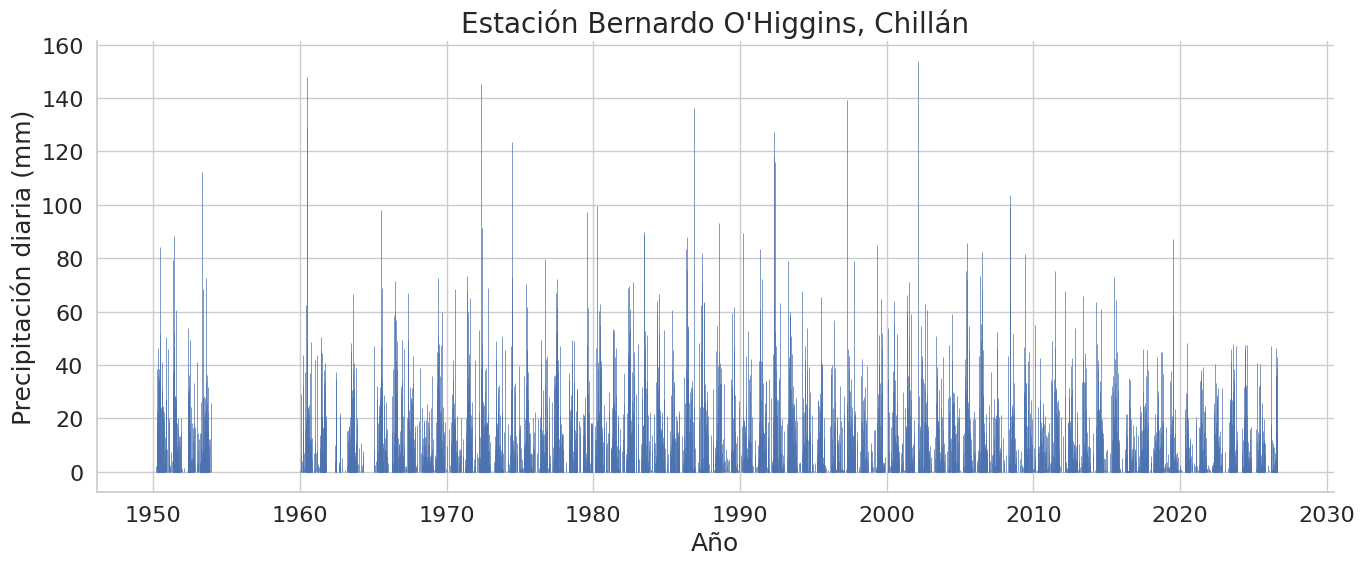

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.vlines(
    datos.index,
    0,
    datos["precipitacion_mm"],
    linewidth=0.5
)

ax.set_xlabel("Año")
ax.set_ylabel("Precipitación diaria (mm)")
ax.set_title("Estación Bernardo O'Higgins, Chillán")

sns.despine()

fig.tight_layout()
plt.show()

## 5. ¿Cómo se distribuyen los valores de precipitación?

La serie temporal muestra **cuándo** ocurrió cada evento, pero no permite observar fácilmente qué magnitudes son más frecuentes.

Para ello utilizaremos un **histograma**.

Un histograma divide el rango de valores en intervalos o clases (`bins`) y cuenta cuántas observaciones se encuentran dentro de cada intervalo.

Esto permite estudiar la **forma de la distribución** de una variable.

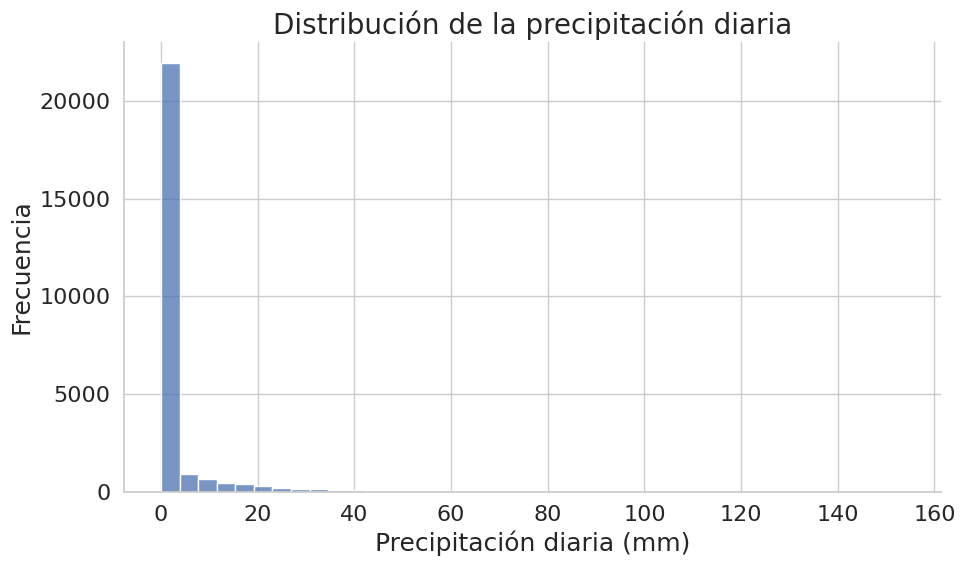

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=datos,
    x="precipitacion_mm",
    bins=40,
    ax=ax
)

ax.set_xlabel("Precipitación diaria (mm)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la precipitación diaria")

sns.despine()

fig.tight_layout()
plt.show()

La distribución de la precipitación diaria es claramente **asimétrica hacia la derecha**.

La mayor parte de las observaciones se concentra en valores bajos, mientras que existe un número reducido de eventos con precipitaciones mucho mayores.

Además, la serie contiene numerosos días con precipitación igual a cero.

Por lo tanto, la distribución está lejos de ser simétrica y un único estadístico puede no representar adecuadamente su comportamiento.

Esto nos lleva a comparar dos medidas de tendencia central:

### Media

La **media aritmética** utiliza todos los valores observados y, por lo tanto, es sensible a valores elevados.

### Mediana

La **mediana** divide las observaciones ordenadas en dos partes:

- 50 % de los valores se encuentra por debajo de la mediana;
- 50 % se encuentra por encima.

En una distribución simétrica, media y mediana pueden ser similares. En una distribución fuertemente asimétrica, pueden ser muy diferentes.

Veamos qué ocurre con nuestros datos.

In [10]:
media = datos["precipitacion_mm"].mean()
mediana = datos["precipitacion_mm"].median()

print(f"Media:   {media:.2f} mm")
print(f"Mediana: {mediana:.2f} mm")

Media:   2.71 mm
Mediana: 0.00 mm


La mediana de la precipitación diaria puede ser **0 mm** si más de la mitad de los días de la serie no registra precipitación.

Esto no significa que la mediana esté mal calculada.

Significa que debemos interpretar el estadístico considerando la naturaleza de los datos.

Una pregunta diferente sería:

> **¿Cómo se distribuye la precipitación cuando efectivamente llueve?**

Para responderla podemos analizar solamente los **días húmedos**.

En este ejercicio definiremos como día húmedo aquel con:

**Precipitación > 1 mm**

In [11]:
dias_humedos = datos[
    datos["precipitacion_mm"] > 1
].copy()

print("Número total de días:", len(datos))
print("Número de días húmedos:", len(dias_humedos))

print()
print(
    f"Media días húmedos:   "
    f"{dias_humedos['precipitacion_mm'].mean():.2f} mm"
)

print(
    f"Mediana días húmedos: "
    f"{dias_humedos['precipitacion_mm'].median():.2f} mm"
)

Número total de días: 25537
Número de días húmedos: 4738

Media días húmedos:   14.51 mm
Mediana días húmedos: 9.35 mm


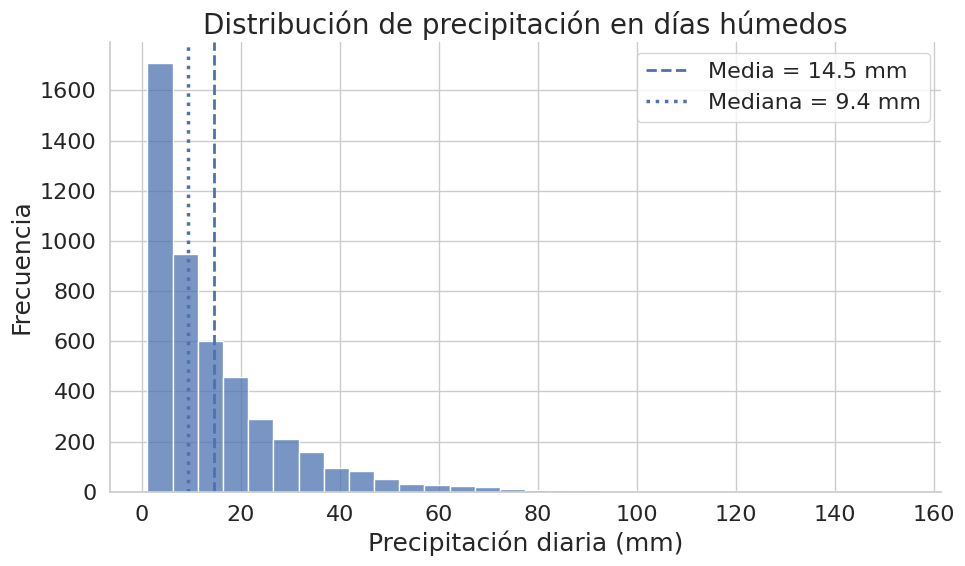

In [12]:
media_humedos = dias_humedos["precipitacion_mm"].mean()
mediana_humedos = dias_humedos["precipitacion_mm"].median()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dias_humedos,
    x="precipitacion_mm",
    bins=30,
    ax=ax
)

ax.axvline(
    media_humedos,
    linestyle="--",
    linewidth=2,
    label=f"Media = {media_humedos:.1f} mm"
)

ax.axvline(
    mediana_humedos,
    linestyle=":",
    linewidth=2.5,
    label=f"Mediana = {mediana_humedos:.1f} mm"
)

ax.set_xlabel("Precipitación diaria (mm)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de precipitación en días húmedos")

ax.legend()

sns.despine()
fig.tight_layout()

plt.show()

## 6. Exportación de figuras: raster y vector

Una figura que se visualiza correctamente en Google Colab no necesariamente tendrá la calidad adecuada cuando se incorpora a un informe, tesis o artículo científico.

Al exportar una figura debemos considerar principalmente:

- el **formato del archivo**;
- el **tamaño de la figura**;
- la **resolución**, cuando corresponde;
- el tamaño y legibilidad de textos, ejes y leyendas.

Los formatos gráficos pueden dividirse en dos grandes grupos:

### Formatos raster

Una imagen **raster** está formada por una matriz de píxeles.

Formatos comunes:

- **PNG** → muy utilizado para gráficos y documentos;
- **JPG/JPEG** → utiliza compresión y es más apropiado para fotografías;
- **TIFF** → frecuente en publicaciones científicas y aplicaciones de alta calidad.

En estos formatos, la calidad depende del número de píxeles y de la resolución utilizada.

La resolución suele expresarse en **dpi** (*dots per inch*, puntos por pulgada).

Por ejemplo, una figura de:

**10 × 6 pulgadas**

guardada a:

**300 dpi**

tendrá aproximadamente:

**3000 × 1800 píxeles**

Una resolución de **300 dpi** es común para figuras destinadas a impresión o publicación, aunque siempre deben revisarse los requisitos específicos de la revista, institución o medio de publicación.

### Formatos vectoriales

Una figura **vectorial** no almacena principalmente una matriz de píxeles. Los elementos gráficos, como líneas, texto y símbolos, se almacenan como objetos geométricos.

Formatos comunes:

- **PDF**
- **SVG**
- **EPS**

Su principal ventaja es que las líneas y textos pueden ampliarse sin perder definición.

Por esta razón, para gráficos científicos formados principalmente por **líneas, puntos, texto y símbolos**, es recomendable conservar una versión vectorial.

### ¿Qué formato utilizar?

Una buena práctica es guardar la figura en ambos formatos:

- **PNG a 300 dpi** → versión raster de alta resolución;
- **PDF** → versión vectorial para documentos y edición posterior.

> **Importante:** `dpi` es fundamental para una imagen raster. En una figura PDF vectorial, las líneas y textos vectoriales no dependen de los dpi de la misma manera y pueden ampliarse sin pixelarse.

No existe un formato universalmente correcto para todas las publicaciones. Antes de enviar una figura a una revista, congreso o institución, siempre deben revisarse sus especificaciones.

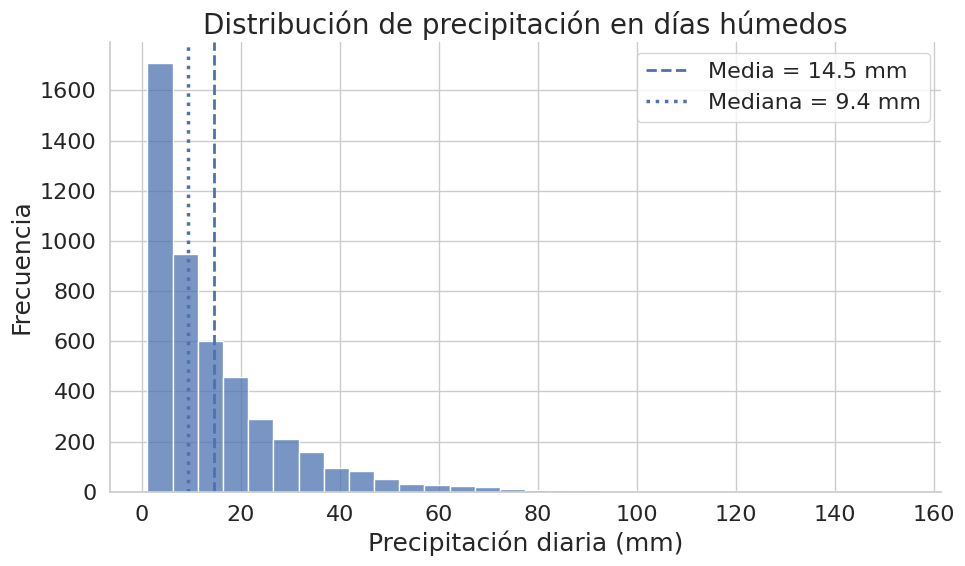

In [14]:
media_humedos = dias_humedos["precipitacion_mm"].mean()
mediana_humedos = dias_humedos["precipitacion_mm"].median()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dias_humedos,
    x="precipitacion_mm",
    bins=30,
    ax=ax
)

ax.axvline(
    media_humedos,
    linestyle="--",
    linewidth=2,
    label=f"Media = {media_humedos:.1f} mm"
)

ax.axvline(
    mediana_humedos,
    linestyle=":",
    linewidth=2.5,
    label=f"Mediana = {mediana_humedos:.1f} mm"
)

ax.set_xlabel("Precipitación diaria (mm)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de precipitación en días húmedos")

ax.legend()

sns.despine()
fig.tight_layout()
plt.show()

# Formato raster de alta resolución
fig.savefig(
    "distribucion_precipitacion_dias_humedos_100dpi.png",
    dpi=100,
    bbox_inches="tight"
)

fig.savefig(
    "distribucion_precipitacion_dias_humedos.png",
    dpi=300,
    bbox_inches="tight"
)

# Formato vectorial
fig.savefig(
    "distribucion_precipitacion_dias_humedos.pdf",
    bbox_inches="tight"
)

### Tamaño de figura y resolución no son lo mismo

En Matplotlib:

`figsize=(10, 6)`

define el tamaño físico de la figura en **pulgadas**.

En cambio:

`dpi=300`

define la cantidad de puntos o píxeles utilizados por cada pulgada cuando guardamos una imagen raster.

Por lo tanto:

**ancho en píxeles = ancho en pulgadas × dpi**

**alto en píxeles = alto en pulgadas × dpi**

Para una figura de `10 × 6` pulgadas a `300 dpi`:

- ancho = 10 × 300 = **3000 píxeles**
- alto = 6 × 300 = **1800 píxeles**

Aumentar los dpi no corrige automáticamente una figura mal diseñada. Los textos, ejes, símbolos y líneas también deben tener tamaños adecuados y ser legibles en el tamaño final en que se utilizará la figura.

## 7. Percentiles y cuartiles

La media y la mediana describen el centro de una distribución, pero no muestran cómo se distribuyen las observaciones a lo largo de todo su rango.

Los **percentiles** permiten dividir una distribución ordenada y responder preguntas como:

- ¿qué valor no supera el 50 % de los días húmedos?
- ¿qué precipitación no supera el 90 % de los eventos?
- ¿qué magnitud es superada solamente por el 5 % de los eventos?

El **percentil p** corresponde al valor por debajo del cual se encuentra aproximadamente el `p %` de las observaciones.

Algunos percentiles reciben nombres especiales:

- **P25 = Q1:** primer cuartil;
- **P50 = Q2:** segundo cuartil o mediana;
- **P75 = Q3:** tercer cuartil.

Para estudiar la parte superior de la distribución también son útiles percentiles como **P90, P95 y P99**.

In [15]:
percentiles = dias_humedos["precipitacion_mm"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

percentiles

,precipitacion_mm
0.25,4.000
0.50,9.350
0.75,19.400
0.90,33.330
0.95,44.100
0.99,71.915


### ¿Cómo interpretamos un percentil?

Supongamos que obtenemos:

**P95 = 45 mm**

Esto significa que aproximadamente:

- el **95 %** de los días húmedos presenta precipitaciones iguales o inferiores a 45 mm;
- el **5 %** presenta precipitaciones superiores a 45 mm.

Por lo tanto, un percentil no indica directamente la probabilidad de que llueva.

Describe la posición de una observación dentro de la **distribución que estamos analizando**.

En este caso estamos trabajando solamente con **días húmedos (> 1 mm)**, por lo que los percentiles describen la magnitud de la precipitación cuando ocurre un día húmedo.

In [16]:
tabla_percentiles = pd.DataFrame({
    "Percentil": ["P25", "P50", "P75", "P90", "P95", "P99"],
    "Precipitación (mm)": percentiles.values
})

tabla_percentiles["Precipitación (mm)"] = (
    tabla_percentiles["Precipitación (mm)"].round(1)
)

tabla_percentiles

,Percentil,Precipitación (mm)
0,P25,4.0
1,P50,9.4
2,P75,19.4
3,P90,33.3
4,P95,44.1
5,P99,71.9


## 8. Distribución empírica y probabilidad de excedencia

Los percentiles describen algunos puntos específicos de la distribución, como P50, P90 o P95.

Sin embargo, también podemos representar **todas las observaciones ordenadas** y asociar a cada una una probabilidad empírica.

Para precipitación resulta especialmente útil trabajar con la **probabilidad de excedencia**:

> **¿Qué proporción de las observaciones iguala o supera una determinada precipitación?**

Para construir esta distribución:

1. ordenamos las precipitaciones de mayor a menor;
2. asignamos un rango `m` a cada observación;
3. calculamos su probabilidad empírica de excedencia.

Utilizaremos la **posición de trazado de Weibull**:

**P = m / (n + 1)**

donde:

- `m` = rango de la observación, ordenada de mayor a menor;
- `n` = número total de observaciones;
- `P` = probabilidad empírica de excedencia.

La observación más grande tiene `m = 1` y, por lo tanto, una probabilidad de excedencia pequeña. A medida que disminuye la precipitación, aumenta la proporción de observaciones que igualan o superan ese valor.

Continuaremos trabajando con los **días húmedos (> 1 mm)**.

In [17]:
# Ordenar las precipitaciones de mayor a menor
excedencia = (
    dias_humedos["precipitacion_mm"]
    .dropna()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

# Número total de observaciones
n = len(excedencia)

# Crear tabla de distribución empírica
distribucion_empirica = pd.DataFrame({
    "precipitacion_mm": excedencia
})

# Rango: 1 corresponde al mayor valor
distribucion_empirica["rango"] = range(1, n + 1)

# Posición de trazado de Weibull
distribucion_empirica["prob_excedencia"] = (
    distribucion_empirica["rango"] / (n + 1)
)

# Expresar también como porcentaje
distribucion_empirica["excedencia_pct"] = (
    distribucion_empirica["prob_excedencia"] * 100
)

distribucion_empirica.head(10)

,precipitacion_mm,rango,prob_excedencia,excedencia_pct
0,153.7,1,0.000211,0.021101
1,148.0,2,0.000422,0.042203
2,145.3,3,0.000633,0.063304
3,139.1,4,0.000844,0.084406
4,136.3,5,0.001055,0.105507
5,129.0,6,0.001266,0.126609
6,127.3,7,0.001477,0.147710
7,123.5,8,0.001688,0.168812
8,118.1,9,0.001899,0.189913
9,115.9,10,0.002110,0.211015


La tabla está ordenada desde el evento de mayor precipitación hasta el menor.

Por ejemplo, una probabilidad de excedencia de **5 %** indica que aproximadamente el 5 % de las observaciones de la distribución analizada iguala o supera esa magnitud.

Es importante recordar qué población estamos analizando:

> En esta sección la probabilidad se calcula sobre los **días húmedos (> 1 mm)**, no sobre todos los días del año.

Por lo tanto, una excedencia del 5 % significa aproximadamente **5 % de los días húmedos**, y no una probabilidad diaria de lluvia del 5 %.

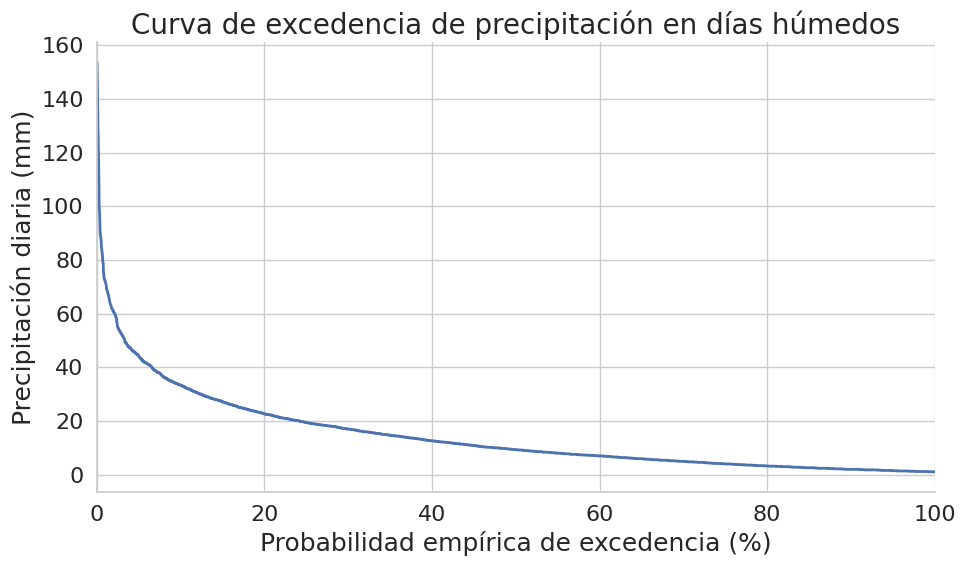

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=distribucion_empirica,
    x="excedencia_pct",
    y="precipitacion_mm",
    ax=ax,
    linewidth=2
)

ax.set_xlabel("Probabilidad empírica de excedencia (%)")
ax.set_ylabel("Precipitación diaria (mm)")
ax.set_title("Curva de excedencia de precipitación en días húmedos")

ax.set_xlim(0, 100)

sns.despine()
fig.tight_layout()

plt.show()

## ¿Cómo interpretar la curva de excedencia?

La curva permite consultar gráficamente qué tan frecuente es superar diferentes magnitudes de precipitación.

Hacia la **izquierda** se encuentran las precipitaciones de mayor magnitud:

- son poco frecuentes;
- presentan probabilidades de excedencia pequeñas.

Hacia la **derecha** aparecen precipitaciones menores:

- son más frecuentes;
- presentan probabilidades de excedencia mayores.

Por ejemplo, podemos preguntarnos:

> ¿Qué precipitación es superada aproximadamente por el 5 % de los días húmedos?

Este concepto está directamente relacionado con los percentiles.

Una probabilidad de excedencia del **5 %** corresponde aproximadamente al **percentil 95 (P95)**, porque:

**95 % no excede el valor ↔ 5 % lo excede.**

Por lo tanto, percentiles y probabilidades de excedencia son dos formas complementarias de describir una distribución.

In [19]:
P95 = dias_humedos["precipitacion_mm"].quantile(0.95)

print(f"P95: {P95:.1f} mm")
print(
    "Probabilidad de excedencia asociada: "
    "aproximadamente 5 %"
)

P95: 44.1 mm
Probabilidad de excedencia asociada: aproximadamente 5 %


## 9. Cuartiles y rango intercuartílico

Los percentiles P25, P50 y P75 reciben nombres especiales y se denominan **cuartiles**:

- **Q1 = P25:** 25 % de las observaciones se encuentra por debajo de este valor.
- **Q2 = P50:** corresponde a la mediana.
- **Q3 = P75:** 75 % de las observaciones se encuentra por debajo de este valor.

La diferencia entre el tercer y primer cuartil se denomina **rango intercuartílico (IQR)**:

**IQR = Q3 − Q1**

El intervalo entre Q1 y Q3 contiene el **50 % central de las observaciones**.

El IQR es una medida de dispersión especialmente útil en distribuciones asimétricas porque, a diferencia del rango total, no está determinado por los valores más extremos.

In [20]:
Q1 = dias_humedos["precipitacion_mm"].quantile(0.25)
Q2 = dias_humedos["precipitacion_mm"].quantile(0.50)
Q3 = dias_humedos["precipitacion_mm"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 (P25): {Q1:.1f} mm")
print(f"Q2 (P50): {Q2:.1f} mm")
print(f"Q3 (P75): {Q3:.1f} mm")
print(f"IQR:      {IQR:.1f} mm")

Q1 (P25): 4.0 mm
Q2 (P50): 9.4 mm
Q3 (P75): 19.4 mm
IQR:      15.4 mm


## 10. Diagrama de caja

El **diagrama de caja o boxplot** resume gráficamente varios de los estadísticos que acabamos de calcular.

La caja está delimitada por **Q1 y Q3**, por lo que contiene el 50 % central de las observaciones.

La línea dentro de la caja representa la **mediana (Q2)**.

Los llamados **bigotes** se extienden hacia valores inferiores y superiores siguiendo un criterio basado en el IQR.

Por defecto, Seaborn utiliza el criterio de **1.5 × IQR**.

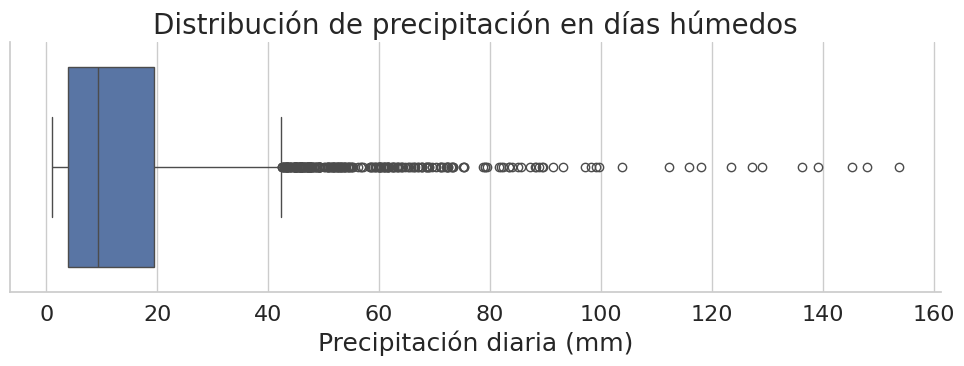

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(
    data=dias_humedos,
    x="precipitacion_mm",
    ax=ax
)

ax.set_xlabel("Precipitación diaria (mm)")
ax.set_title("Distribución de precipitación en días húmedos")

sns.despine()
fig.tight_layout()

plt.show()

### Valores atípicos y la regla de 1.5 × IQR

Los límites utilizados para identificar observaciones alejadas de la parte central de la distribución se calculan como:

**Límite inferior = Q1 − 1.5 × IQR**

**Límite superior = Q3 + 1.5 × IQR**

Las observaciones situadas fuera de estos límites aparecen como puntos individuales en el boxplot y suelen denominarse **valores atípicos** (*outliers*).

Sin embargo, esta clasificación es **estadística**, no un criterio automático de control de calidad.

En una variable como la precipitación, un evento muy intenso puede ser poco frecuente y aparecer como outlier, pero ser una observación perfectamente válida.

> **Outlier no significa error.**

Antes de eliminar una observación debemos revisar su origen, consistencia y contexto.

In [22]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límite inferior: {limite_inferior:.1f} mm")
print(f"Límite superior: {limite_superior:.1f} mm")

Límite inferior: -19.1 mm
Límite superior: 42.5 mm


Estos límites se obtienen únicamente a partir de la distribución de los datos y **no consideran las restricciones físicas de la variable**.

En nuestro caso, el límite inferior calculado es negativo. Esto no significa que una precipitación negativa sea posible.

La precipitación tiene un límite físico inferior de **0 mm**. Por lo tanto, un límite estadístico negativo simplemente indica que, para esta distribución, no esperamos identificar outliers inferiores físicamente válidos mediante la regla de 1.5 × IQR.

Esta diferencia es importante:

> **Los límites estadísticos y los límites físicamente posibles de una variable no son necesariamente iguales.**

Del mismo modo, superar el límite superior del boxplot no significa que una precipitación sea incorrecta. Un evento extremo real puede encontrarse fuera de los bigotes.

In [23]:
eventos_atipicos = dias_humedos[
    dias_humedos["precipitacion_mm"] > limite_superior
]

print("Número de eventos sobre el límite:", len(eventos_atipicos))

eventos_atipicos.sort_values(
    "precipitacion_mm",
    ascending=False
).head(10)

Número de eventos sobre el límite: 259


,precipitacion_mm
fecha,
2002-02-26,153.7
1960-06-20,148.0
1972-05-07,145.3
1997-04-22,139.1
1986-11-25,136.3
1960-06-18,129.0
1992-05-04,127.3
1974-06-26,123.5
1992-05-03,118.1


El boxplot identifica varios eventos de precipitación elevada como valores atípicos debido a su posición respecto del resto de la distribución.

Pero en hidrología estos eventos pueden ser precisamente algunos de los datos de mayor interés.

En lugar de eliminarlos, podemos formular otra pregunta:

> **¿Cuáles fueron los eventos de precipitación más extremos de cada año?**

Para responderla construiremos una **serie de máximos anuales**, seleccionando la mayor precipitación diaria registrada en cada año.

Esta transformación nos permitirá pasar del análisis descriptivo de todos los días húmedos al análisis de **extremos anuales**.

## 11. Serie de máximos anuales

Hasta ahora analizamos la distribución de todos los días húmedos.

Sin embargo, para estudiar eventos extremos podemos construir una serie diferente: la **serie de máximos anuales**.

Para cada año seleccionaremos únicamente:

> **la mayor precipitación diaria registrada durante ese año.**

Si disponemos de 70 años completos de información, obtendremos aproximadamente 70 valores: un máximo por año.

Este procedimiento reduce considerablemente el número de observaciones, pero permite concentrar el análisis en los eventos extremos.

En Pandas podemos obtener los máximos anuales utilizando `resample()` y la función `max()`.

In [24]:
maximos_anuales = (
    datos["precipitacion_mm"]
    .resample("YE")
    .max()
    .dropna()
)

maximos_anuales.head()

,precipitacion_mm
fecha,
1950-12-31,84.0
1951-12-31,88.3
1952-12-31,53.7
1953-12-31,112.3
1959-12-31,0.0


### ¿Todos los años pueden utilizarse?

`resample("YE").max()` seleccionará el máximo disponible incluso si un año contiene muchos datos faltantes.

Esto puede ser problemático: si faltan varios meses, el máximo observado podría no representar adecuadamente el máximo anual.

Por esta razón, antes de continuar comprobaremos la **completitud de cada año**.

Para este ejercicio consideraremos un año válido cuando tenga al menos **90 % de sus días con datos disponibles**.

In [25]:
# Número de observaciones válidas por año
dias_validos = (
    datos["precipitacion_mm"]
    .resample("YE")
    .count()
)

# Número de días esperados en cada año
dias_esperados = pd.Series(
    maximos_anuales.index.is_leap_year + 365,
    index=maximos_anuales.index
)

# Proporción de completitud
completitud_anual = dias_validos / dias_esperados

# Mantener solamente años con al menos 90 % de datos
maximos_anuales = maximos_anuales[
    completitud_anual >= 0.90
]

print("Número de años válidos:", len(maximos_anuales))

Número de años válidos: 69


### Evolución de los máximos anuales

Antes de ordenar los extremos según su magnitud, mantendremos su orden cronológico.

Esto permite observar cómo han variado los máximos diarios anuales a lo largo del periodo disponible.

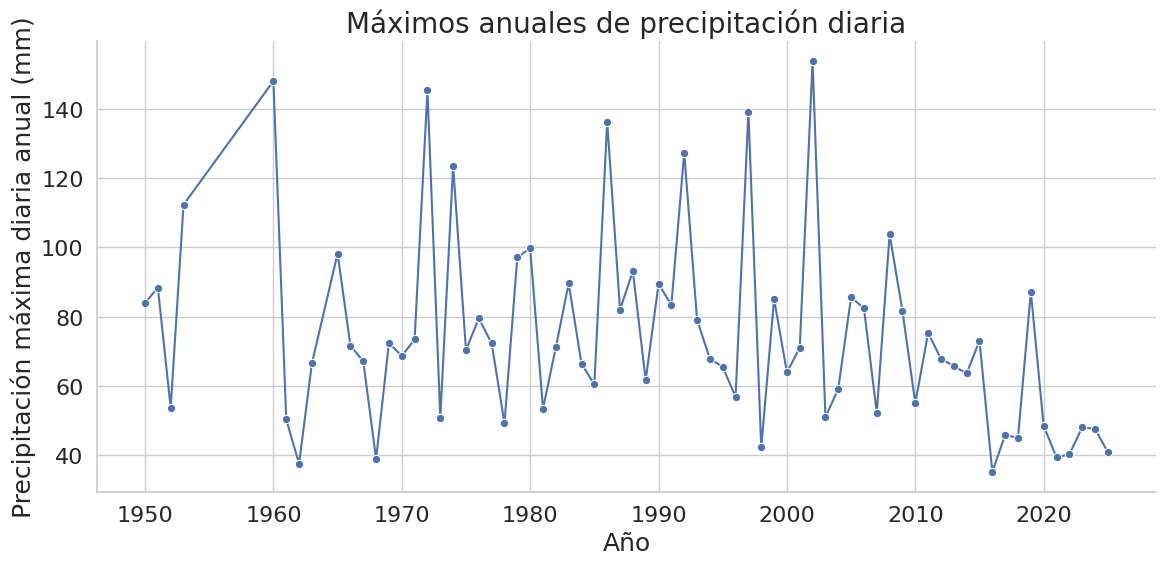

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    x=maximos_anuales.index.year,
    y=maximos_anuales.values,
    marker="o",
    linewidth=1.5,
    ax=ax
)

ax.set_xlabel("Año")
ax.set_ylabel("Precipitación máxima diaria anual (mm)")
ax.set_title("Máximos anuales de precipitación diaria")

sns.despine()
fig.tight_layout()

plt.show()

## 12. Posición de Weibull para máximos anuales

Ahora dejaremos de considerar el orden cronológico y ordenaremos los máximos anuales **de mayor a menor**.

Asignaremos un rango `m`:

- `m = 1` → mayor máximo anual observado;
- `m = 2` → segundo mayor;
- `m = 3` → tercero mayor;
- etc.

Para una muestra de `n` años, utilizaremos nuevamente la posición de trazado de Weibull:

**P = m / (n + 1)**

En este caso, `P` representa la **probabilidad empírica anual de excedencia** asociada a cada máximo anual.

In [27]:
extremos = (
    maximos_anuales
    .sort_values(ascending=False)
    .reset_index()
)

extremos.columns = ["fecha", "precipitacion_mm"]

extremos["agno"] = extremos["fecha"].dt.year

n = len(extremos)

extremos["rango"] = range(1, n + 1)

extremos["prob_excedencia"] = (
    extremos["rango"] / (n + 1)
)

extremos.head(10)

,fecha,precipitacion_mm,agno,rango,prob_excedencia
0,2002-12-31,153.7,2002,1,0.014286
1,1960-12-31,148.0,1960,2,0.028571
2,1972-12-31,145.3,1972,3,0.042857
3,1997-12-31,139.1,1997,4,0.057143
4,1986-12-31,136.3,1986,5,0.071429
5,1992-12-31,127.3,1992,6,0.085714
6,1974-12-31,123.5,1974,7,0.100000
7,1953-12-31,112.3,1953,8,0.114286
8,2008-12-31,103.8,2008,9,0.128571
9,1980-12-31,99.7,1980,10,0.142857


## 13. Periodo de retorno empírico

Cuando trabajamos con una serie de **máximos anuales**, podemos expresar la probabilidad anual de excedencia mediante su inverso: el **periodo de retorno**.

Si `P` es la probabilidad anual de excedencia:

**T = 1 / P**

Combinando esta expresión con la posición de Weibull:

**T = (n + 1) / m**

donde:

- `T` = periodo de retorno empírico, en años;
- `n` = número de años de la serie;
- `m` = rango del evento.

Un periodo de retorno de 20 años corresponde a una probabilidad anual de excedencia de:

**P = 1 / 20 = 0.05 = 5 %**

In [28]:
extremos["periodo_retorno"] = (
    1 / extremos["prob_excedencia"]
)

extremos[
    [
        "agno",
        "precipitacion_mm",
        "rango",
        "prob_excedencia",
        "periodo_retorno"
    ]
].head(10)

,agno,precipitacion_mm,rango,prob_excedencia,periodo_retorno
0,2002,153.7,1,0.014286,70.000000
1,1960,148.0,2,0.028571,35.000000
2,1972,145.3,3,0.042857,23.333333
3,1997,139.1,4,0.057143,17.500000
4,1986,136.3,5,0.071429,14.000000
5,1992,127.3,6,0.085714,11.666667
6,1974,123.5,7,0.100000,10.000000
7,1953,112.3,8,0.114286,8.750000
8,2008,103.8,9,0.128571,7.777778
9,1980,99.7,10,0.142857,7.000000


### ¿Qué significa un periodo de retorno de 20 años?

Un periodo de retorno de 20 años **no significa** que el evento ocurrirá exactamente una vez cada 20 años.

Significa que, bajo las condiciones representadas por los datos, el evento tiene aproximadamente una:

**1 / 20 = 5 %**

de probabilidad de ser igualado o superado en cualquier año.

Dos eventos de este tipo podrían ocurrir en años consecutivos, o podrían transcurrir más de 20 años sin que ocurra ninguno.

Además, los periodos de retorno que estamos calculando aquí son **empíricos**: se obtienen directamente del ordenamiento de los máximos observados y no del ajuste de una distribución probabilística.

## 14. Curva empírica de periodo de retorno

Ahora podemos representar conjuntamente:

- la **magnitud de la precipitación máxima diaria anual**;
- su **periodo de retorno empírico**.

Esta representación permite observar cómo aumenta la magnitud de los eventos a medida que disminuye su frecuencia de ocurrencia.

Utilizaremos:

- **Eje X:** periodo de retorno `T` (años);
- **Eje Y:** precipitación máxima diaria anual (mm).

El periodo de retorno se representará utilizando una **escala logarítmica**.

Una escala logarítmica es útil cuando una variable abarca valores de diferente orden de magnitud. En este caso permite visualizar mejor periodos de retorno pequeños y grandes dentro de una misma figura.

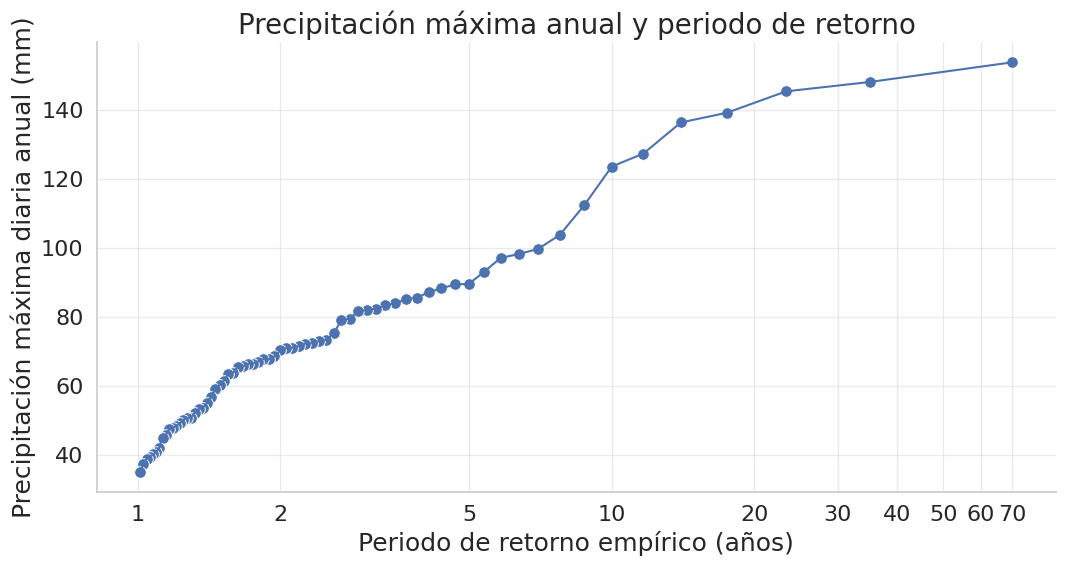

In [31]:
fig, ax = plt.subplots(figsize=(11, 6))

# Puntos
sns.scatterplot(
    data=extremos,
    x="periodo_retorno",
    y="precipitacion_mm",
    s=70,
    ax=ax
)

# Línea
sns.lineplot(
    data=extremos.sort_values("periodo_retorno"),
    x="periodo_retorno",
    y="precipitacion_mm",
    linewidth=1.5,
    ax=ax
)

# Escala logarítmica
ax.set_xscale("log")

# Valores que queremos mostrar explícitamente
ticks = [1, 2, 5, 10, 20, 30, 40, 50, 60, 70]

# Mostrar solamente los que están dentro del rango de los datos
max_T = extremos["periodo_retorno"].max()
ticks = [t for t in ticks if t <= max_T]

ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])

ax.set_xlabel("Periodo de retorno empírico (años)")
ax.set_ylabel("Precipitación máxima diaria anual (mm)")
ax.set_title("Precipitación máxima anual y periodo de retorno")

ax.grid(True, which="major", alpha=0.4)

sns.despine()
fig.tight_layout()

plt.show()

### ¿Cómo interpretamos la figura?

Cada punto corresponde al **máximo diario de precipitación de un año**.

Los eventos más frecuentes se encuentran hacia la izquierda de la figura y presentan periodos de retorno pequeños.

Los eventos de mayor magnitud aparecen progresivamente hacia la derecha y presentan periodos de retorno mayores.

Por ejemplo:

- `T = 2 años` corresponde a una probabilidad anual de excedencia de aproximadamente 50 %;
- `T = 5 años` corresponde a aproximadamente 20 %;
- `T = 10 años` corresponde a aproximadamente 10 %;
- `T = 20 años` corresponde a aproximadamente 5 %.

La escala logarítmica modifica la separación visual entre los valores del eje X, pero **no modifica los datos ni el periodo de retorno calculado**.

In [30]:
tabla_extremos = extremos[
    [
        "agno",
        "precipitacion_mm",
        "prob_excedencia",
        "periodo_retorno"
    ]
].copy()

tabla_extremos["prob_excedencia"] = (
    tabla_extremos["prob_excedencia"] * 100
)

tabla_extremos.columns = [
    "Año",
    "Precipitación (mm)",
    "Prob. excedencia (%)",
    "Periodo retorno (años)"
]

tabla_extremos = tabla_extremos.round({
    "Precipitación (mm)": 1,
    "Prob. excedencia (%)": 2,
    "Periodo retorno (años)": 1
})

tabla_extremos.head(10)

,Año,Precipitación (mm),Prob. excedencia (%),Periodo retorno (años)
0,2002,153.7,1.43,70.0
1,1960,148.0,2.86,35.0
2,1972,145.3,4.29,23.3
3,1997,139.1,5.71,17.5
4,1986,136.3,7.14,14.0
5,1992,127.3,8.57,11.7
6,1974,123.5,10.00,10.0
7,1953,112.3,11.43,8.8
8,2008,103.8,12.86,7.8
9,1980,99.7,14.29,7.0


### Periodo de retorno empírico ≠ predicción de eventos no observados

La curva que hemos construido es una **distribución empírica**.

Esto significa que utilizamos exclusivamente los eventos observados durante el periodo disponible y les asignamos una posición de acuerdo con su rango.

Por ejemplo, si disponemos de `n` años, el mayor periodo de retorno que podemos asignar mediante la posición de Weibull es aproximadamente:

**T = n + 1 años**

No podemos utilizar esta curva empírica para estimar directamente, por ejemplo, una precipitación con periodo de retorno de **100, 200 o 500 años** cuando estos periodos se encuentran fuera del rango representado por la muestra.

Para realizar este tipo de estimaciones es necesario avanzar hacia un **análisis de frecuencia de extremos**, ajustando una distribución probabilística apropiada y evaluando sus supuestos e incertidumbre.

Ese procedimiento corresponde a una etapa diferente del análisis.

### Periodo de retorno y riesgo durante varios años

Un evento con periodo de retorno de 100 años tiene una probabilidad anual de excedencia de aproximadamente:

**P = 1 / 100 = 1 %**

Pero esto **no significa** que debamos esperar exactamente 100 años entre dos eventos.

Tampoco significa que la probabilidad de observarlo durante un periodo de varias décadas sea solamente 1 %.

El periodo de retorno describe una **probabilidad anual**. Cuando consideramos varios años, la probabilidad acumulada de observar al menos una excedencia aumenta.

Este concepto es particularmente importante en el diseño y evaluación de infraestructura hidráulica.

## 15. De los datos a la interpretación

A lo largo de este notebook analizamos una misma serie de precipitación desde diferentes perspectivas.

Comenzamos observando la serie temporal y su distribución. A partir de ella vimos que la precipitación diaria presenta una distribución fuertemente asimétrica y que una gran proporción de los días registra precipitación nula.

Posteriormente analizamos únicamente los días húmedos y utilizamos diferentes herramientas para caracterizar su distribución:

- **Media y mediana:** permiten describir el centro de la distribución, pero responden de manera diferente frente a distribuciones asimétricas y valores extremos.
- **Percentiles:** permiten identificar la posición relativa de diferentes magnitudes dentro de la distribución.
- **Curva de excedencia:** muestra con qué frecuencia empírica se igualan o superan diferentes magnitudes.
- **Cuartiles e IQR:** describen el 50 % central de las observaciones.
- **Boxplot:** resume gráficamente la distribución y permite identificar observaciones alejadas de su parte central.
- **Máximos anuales:** permiten concentrar el análisis en los eventos más extremos registrados cada año.
- **Posición de Weibull:** permite asignar una probabilidad empírica de excedencia a los máximos anuales.
- **Periodo de retorno:** expresa la probabilidad anual de excedencia en una forma habitual en hidrología e ingeniería.

Estas herramientas no responden exactamente la misma pregunta.

> El análisis exploratorio de datos consiste en combinar diferentes estadísticos y visualizaciones para comprender los datos antes de realizar análisis o modelos más complejos.

# Evaluación 2: Exploración de precipitación en una estación de Chile

Aplicar las herramientas de análisis exploratorio desarrolladas durante la clase a una **estación de precipitación diferente** a la utilizada en el ejemplo.

Cada estudiante deberá seleccionar una estación del **Explorador Climático CR2** que cumpla con:

- disponer de **al menos 30 años de registros** de precipitación diaria;
- contar con información suficiente para construir una serie de máximos anuales;


El resultado se presentará mediante una **presentación oral de máximo 5 diapositivas**.


## Presentación

**Número máximo de diapositivas:** 7  
**Tiempo máximo:** 10 minutos  
**Formato de entrega:** PDF  y defensa oral

El tiempo será controlado durante la presentación.

La presentación debe centrarse en los **resultados obtenidos para la estación seleccionada y su interpretación**.

No dedique diapositivas a explicar conceptos generales como:

- qué es la media;
- qué es un percentil;
- qué es un boxplot;
- qué es la posición de Weibull;
- qué es un periodo de retorno.

Estos conceptos ya fueron desarrollados durante la clase.

> **El objetivo es interpretar los datos de su estación, no repetir la teoría del notebook.**


## Diapositiva sobre Estación y datos

Presente brevemente:

- nombre de la estación;
- ubicación;
- periodo disponible;
- número de años de registro;
- porcentaje o cantidad de datos disponibles;
- fuente de los datos.

Incluya una representación de la **serie temporal de precipitación diaria**.

Utilice esta diapositiva para discutir la calidad y extensión de la información.

Por ejemplo:

- ¿la serie cubre todo el periodo de manera continua?;
- ¿existen periodos con datos faltantes?;
- ¿cuántos años cumplen el criterio de al menos 90 % de completitud?;
- ¿la extensión de la serie es suficiente para los análisis posteriores?


## Diapositiva sobre Distribución de la precipitación

Caracterice la distribución de la precipitación mediante las herramientas desarrolladas en clase.

Puede incluir:

- histograma;
- media y mediana de los días húmedos;
- percentiles;
- P90, P95 y P99.

La presentación debe interpretar los resultados.

Por ejemplo:

- ¿qué tan asimétrica es la distribución?;
- ¿cuánto difieren media y mediana y por qué?;
- ¿qué magnitudes representan P90, P95 y P99?;
- ¿qué indican estos valores sobre los eventos de mayor precipitación?


## Diapositiva sobre Distribución empírica y valores extremos

Utilice:

- curva de probabilidad empírica de excedencia;
- boxplot;
- IQR y límites de 1.5 × IQR cuando sean relevantes.

Discuta:

- ¿qué magnitudes presentan probabilidades pequeñas de excedencia?;
- ¿qué observa en la parte superior de la distribución?;
- ¿cuántos valores son identificados como outliers?;
- ¿son necesariamente datos incorrectos?;
- ¿son coherentes con el comportamiento de la precipitación de la estación?

No elimine automáticamente los valores extremos identificados por el boxplot.


## Diapositiva sobre Máximos anuales

Construya la serie de **máximos diarios anuales**.

Para este análisis utilice solamente años que tengan al menos **90 % de los datos diarios disponibles**.

Presente:

- evolución de los máximos anuales;
- número de años válidos utilizados;
- principales eventos extremos observados.

Interprete los resultados considerando la longitud de la serie.

Por ejemplo, una estación con 32 años válidos y otra con 70 años válidos **no proporcionan la misma cantidad de información sobre eventos poco frecuentes**.


## Diapositiva sobre Periodo de retorno y conclusiones

Utilice la posición de Weibull para calcular:

- probabilidad anual de excedencia;
- periodo de retorno empírico.

Presente la relación entre **precipitación máxima diaria anual y periodo de retorno**.

Interprete:

- magnitudes asociadas aproximadamente a T = 2, 5, 10 y 20 años, cuando la longitud de la serie permita analizarlas;
- evento de mayor magnitud observado;
- periodo de retorno empírico asignado al mayor evento;
- limitaciones impuestas por el número de años disponibles.

Finalice con **2–3 conclusiones específicas de su estación**.


# Interpretación de las figuras

Cada figura debe tener un propósito.

Durante la presentación **no describa simplemente lo que ya puede verse en el gráfico**.

Evite:

> “En esta figura se muestra la precipitación máxima anual.”


# Calidad de las figuras

Todas las figuras deben tener calidad adecuada para una presentación científica:

- ejes identificados;
- unidades;
- fuentes legibles;
- escalas apropiadas;
- títulos o pies de figura informativos;
- leyendas solamente cuando sean necesarias.


# Evaluación

Se considerará principalmente:

- correcta aplicación de los análisis desarrollados en clase;
- calidad y legibilidad de las figuras;
- interpretación de los resultados;
- relación entre diferentes indicadores;
- consideración de la longitud y completitud de la serie;
- capacidad para reconocer las limitaciones del análisis;
- claridad y síntesis de la presentación;
- cumplimiento del máximo de **5 diapositivas y 10 minutos**.

> **No se evaluará positivamente repetir definiciones o teoría vista en clase. La presentación debe demostrar qué aprendió sobre la precipitación de la estación seleccionada a partir de sus datos.**

Fecha de entrega: Domingo 18 de octubre, 23h59
Fecha de presentación: Lunes 19 de octubre.